In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score,accuracy_score
import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import mean_absolute_error, mean_squared_error,r2_score



In [2]:
df = pd.read_csv("Covid.csv")

In [3]:
df

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,9/12/20,9/13/20,9/14/20,9/15/20,9/16/20,9/17/20,9/18/20,9/19/20,9/20/20,9/21/20
0,NaN,Afghanistan,33.939110,67.709953,0,0,0,0,0,0,...,38641,38716,38772,38815,38855,38872,38883,38919,39044,39074
1,NaN,Albania,41.153300,20.168300,0,0,0,0,0,0,...,11185,11353,11520,11672,11816,11948,12073,12226,12385,12535
2,NaN,Algeria,28.033900,1.659600,0,0,0,0,0,0,...,48007,48254,48496,48734,48966,49194,49413,49623,49826,50023
3,NaN,Andorra,42.506300,1.521800,0,0,0,0,0,0,...,1344,1344,1438,1438,1483,1483,1564,1564,1564,1681
4,NaN,Angola,-11.202700,17.873900,0,0,0,0,0,0,...,3335,3388,3439,3569,3675,3789,3848,3901,3991,4117
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,NaN,West Bank and Gaza,31.952200,35.233200,0,0,0,0,0,0,...,29906,30574,31362,32250,33006,33843,34401,35003,35686,36151
262,NaN,Western Sahara,24.215500,-12.885800,0,0,0,0,0,0,...,10,10,10,10,10,10,10,10,10,10
263,NaN,Yemen,15.552727,48.516388,0,0,0,0,0,0,...,2009,2011,2013,2016,2019,2022,2024,2026,2026,2028
264,NaN,Zambia,-13.133897,27.849332,0,0,0,0,0,0,...,13466,13539,13720,13819,13887,13928,14022,14070,14131,14175


In [4]:
df.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,9/12/20,9/13/20,9/14/20,9/15/20,9/16/20,9/17/20,9/18/20,9/19/20,9/20/20,9/21/20
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,38641,38716,38772,38815,38855,38872,38883,38919,39044,39074
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,11185,11353,11520,11672,11816,11948,12073,12226,12385,12535
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,48007,48254,48496,48734,48966,49194,49413,49623,49826,50023
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,1344,1344,1438,1438,1483,1483,1564,1564,1564,1681
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,3335,3388,3439,3569,3675,3789,3848,3901,3991,4117


In [5]:
df.tail()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,9/12/20,9/13/20,9/14/20,9/15/20,9/16/20,9/17/20,9/18/20,9/19/20,9/20/20,9/21/20
261,NaN,West Bank and Gaza,31.952200,35.233200,0,0,0,0,0,0,...,29906,30574,31362,32250,33006,33843,34401,35003,35686,36151
262,NaN,Western Sahara,24.215500,-12.885800,0,0,0,0,0,0,...,10,10,10,10,10,10,10,10,10,10
263,NaN,Yemen,15.552727,48.516388,0,0,0,0,0,0,...,2009,2011,2013,2016,2019,2022,2024,2026,2026,2028
264,NaN,Zambia,-13.133897,27.849332,0,0,0,0,0,0,...,13466,13539,13720,13819,13887,13928,14022,14070,14131,14175
265,NaN,Zimbabwe,-19.015438,29.154857,0,0,0,0,0,0,...,7508,7526,7531,7576,7598,7633,7647,7672,7683,7683


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Columns: 248 entries, Province/State to 9/21/20
dtypes: float64(2), int64(244), object(2)
memory usage: 515.5+ KB


In [7]:
df.describe()

,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,...,9/12/20,9/13/20,9/14/20,9/15/20,9/16/20,9/17/20,9/18/20,9/19/20,9/20/20,9/21/20
count,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,266.000000,...,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02,2.660000e+02
mean,21.076624,22.829441,2.086466,2.458647,3.537594,5.390977,7.962406,11.003759,20.969925,23.180451,...,1.081163e+05,1.090052e+05,1.100551e+05,1.111201e+05,1.122630e+05,1.134410e+05,1.146599e+05,1.157171e+05,1.166240e+05,1.174654e+05
std,24.904600,70.191330,27.279200,27.377862,34.083035,47.434934,66.289178,89.313757,219.187744,220.524977,...,5.678329e+05,5.727452e+05,5.774877e+05,5.831820e+05,5.891235e+05,5.953081e+05,6.017349e+05,6.076737e+05,6.126599e+05,6.154886e+05
min,-51.796300,-135.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,6.677575,-15.277675,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,4.672500e+02,4.675000e+02,4.675000e+02,4.682500e+02,4.682500e+02,4.707500e+02,4.707500e+02,4.707500e+02,4.707500e+02,4.710000e+02
50%,22.820850,20.921188,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,3.354500e+03,3.381000e+03,3.397000e+03,3.459000e+03,3.466000e+03,3.522500e+03,3.608000e+03,3.714500e+03,3.772000e+03,3.823500e+03
75%,41.143200,77.913685,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,3.472475e+04,3.540750e+04,3.553900e+04,3.580200e+04,3.599400e+04,3.639525e+04,3.670825e+04,3.731275e+04,3.781650e+04,3.826325e+04
max,71.706900,178.065000,444.000000,444.000000,549.000000,761.000000,1058.000000,1423.000000,3554.000000,3554.000000,...,6.485123e+06,6.520122e+06,6.553652e+06,6.592342e+06,6.630051e+06,6.674411e+06,6.723933e+06,6.768119e+06,6.804814e+06,6.856884e+06


In [8]:
df.isnull()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,9/12/20,9/13/20,9/14/20,9/15/20,9/16/20,9/17/20,9/18/20,9/19/20,9/20/20,9/21/20
0,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
262,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
263,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
264,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [9]:
df.isnull().sum()

Province/State    185
Country/Region      0
Lat                 0
Long                0
1/22/20             0
                 ... 
9/17/20             0
9/18/20             0
9/19/20             0
9/20/20             0
9/21/20             0
Length: 248, dtype: int64

In [10]:
df.shape

(266, 248)

In [11]:
# Detect date columns (format like M/D/YY)
date_cols = [c for c in df.columns if c.count('/')==2]
print("Detected {len(date_cols)} date columns (example):", date_cols[:10])

Detected {len(date_cols)} date columns (example): ['1/22/20', '1/23/20', '1/24/20', '1/25/20', '1/26/20', '1/27/20', '1/28/20', '1/29/20', '1/30/20', '1/31/20']


In [12]:
# Non-date columns
non_date_cols = [c for c in df.columns if c not in date_cols]
print("Non-date / metadata columns:", non_date_cols)



Non-date / metadata columns: ['Province/State', 'Country/Region', 'Lat', 'Long']


In [15]:
# Define a default country (change as needed)
country = 'India'  # or any country that exists in your dataset

if 'Country/Region' in df.columns:
    # aggregate date columns by country
    country_df = df.groupby(['Country/Region'])[date_cols].sum().reset_index()
else:
    # fallback: if there's no Country/Region, attempt to use first non-date column
    id_col = non_date_cols[0] if non_date_cols else df.columns[0]
    country_df = df.groupby([id_col])[date_cols].sum().reset_index()
    df = df.rename(columns={id_col: 'Country/Region'})

# Now this will work because 'country' is defined
if country not in country_df['Country/Region'].values:
    country = country_df['Country/Region'].iloc[0]
    print("Default country not found; switched to:", country)

# Create time series (cumulative -> daily new cases)
ts = country_df[country_df['Country/Region'] == country].iloc[0, 1:].T
ts.index = pd.to_datetime(ts.index)
ts = ts.rename('cumulative_cases').to_frame().sort_index()
ts['new_cases'] = ts['cumulative_cases'].diff().fillna(0)
display(ts.tail(10))
print("Target: 'new_cases' (one-step ahead forecasting).")


,cumulative_cases,new_cases
2020-09-12,4754356,94372
2020-09-13,4846427,92071
2020-09-14,4930236,83809
2020-09-15,5020359,90123
2020-09-16,5118253,97894
2020-09-17,5214677,96424
2020-09-18,5308014,93337
2020-09-19,5400619,92605
2020-09-20,5487580,86961
2020-09-21,5487580,0


Target: 'new_cases' (one-step ahead forecasting).


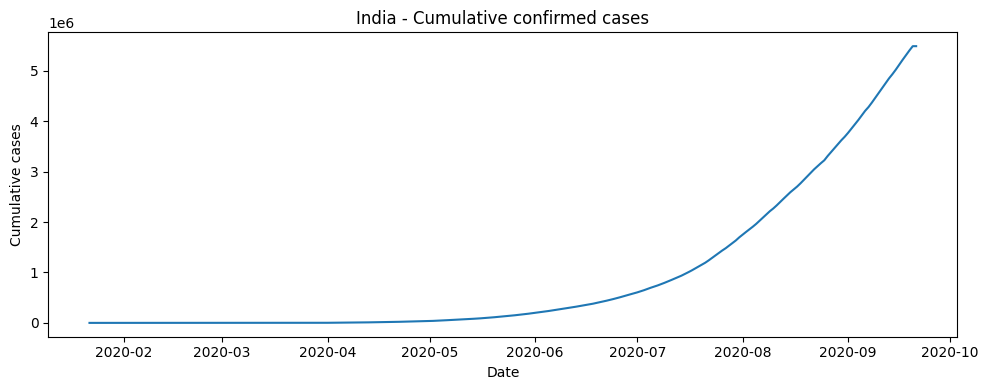

In [16]:
plt.figure(figsize=(10,4))
plt.plot(ts.index, ts['cumulative_cases'])
plt.title(f"{country} - Cumulative confirmed cases")
plt.xlabel("Date");
plt.ylabel("Cumulative cases")
plt.tight_layout();
plt.show()


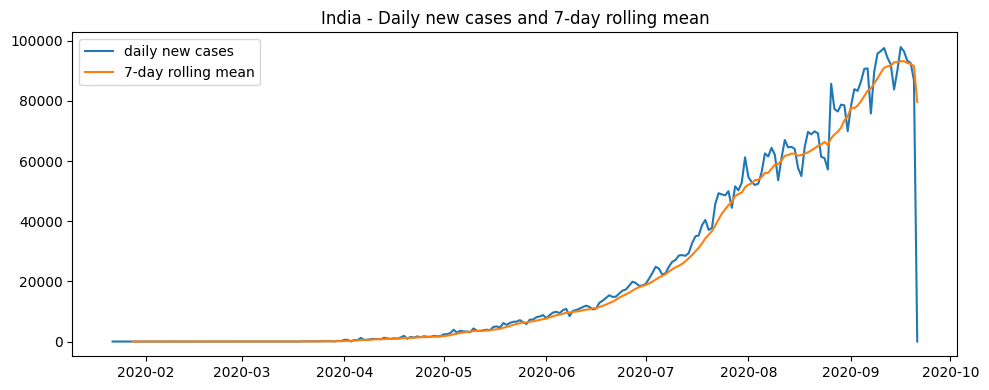

In [17]:
plt.figure(figsize=(10,4))
plt.plot(ts.index, ts['new_cases'], label='daily new cases')
plt.plot(ts.index, ts['new_cases'].rolling(7).mean(), label='7-day rolling mean')
plt.title(f"{country} - Daily new cases and 7-day rolling mean"); plt.legend()
plt.tight_layout(); plt.show()

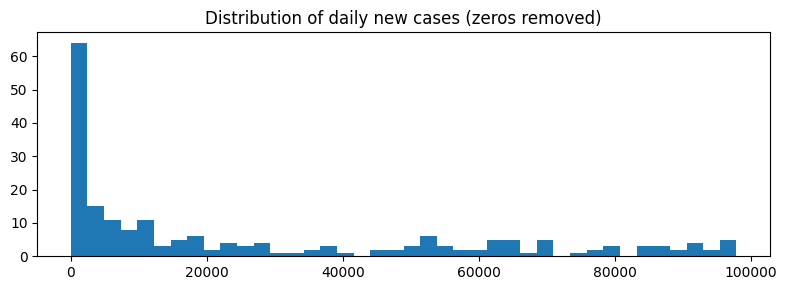

In [18]:
plt.figure(figsize=(8,3))
plt.hist(ts['new_cases'].replace(0, np.nan).dropna(), bins=40)
plt.title("Distribution of daily new cases (zeros removed)"); plt.tight_layout(); plt.show()

In [19]:
# Feature Engineering:

In [20]:
df_ts = ts.copy()
lags = [1,2,3,7,14]
for lag in lags:
    df_ts[f'lag_{lag}'] = df_ts['new_cases'].shift(lag)
df_ts['roll_mean_7'] = df_ts['new_cases'].rolling(7).mean()
df_ts['roll_std_7'] = df_ts['new_cases'].rolling(7).std()
df_ts['dayofweek'] = df_ts.index.dayofweek
df_ts['month'] = df_ts.index.month

In [21]:
# Add static country metadata if available (Lat/Long)
if 'Lat' in df.columns and 'Long' in df.columns and 'Country/Region' in df.columns:
    meta = df.groupby('Country/Region')[['Lat','Long']].mean().reset_index()
    if country in meta['Country/Region'].values:
        lat_val = float(meta[meta['Country/Region']==country]['Lat'])
        long_val = float(meta[meta['Country/Region']==country]['Long'])
        df_ts['country_lat'] = lat_val
        df_ts['country_long'] = long_val
display(df_ts.head())

,cumulative_cases,new_cases,lag_1,lag_2,lag_3,lag_7,lag_14,roll_mean_7,roll_std_7,dayofweek,month,country_lat,country_long
2020-01-22,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,1,20.593684,78.96288
2020-01-23,0,0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,3,1,20.593684,78.96288
2020-01-24,0,0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,4,1,20.593684,78.96288
2020-01-25,0,0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,5,1,20.593684,78.96288
2020-01-26,0,0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,6,1,20.593684,78.96288


In [22]:
# Drop NA rows (from lags/rolling)
df_ts = df_ts.dropna().copy()
print("Features ready. Shape:", df_ts.shape)
display(df_ts.head())


Features ready. Shape: (230, 13)


,cumulative_cases,new_cases,lag_1,lag_2,lag_3,lag_7,lag_14,roll_mean_7,roll_std_7,dayofweek,month,country_lat,country_long
2020-02-05,3,0,0.0,1.0,1.0,0.0,0.0,0.428571,0.534522,2,2,20.593684,78.96288
2020-02-06,3,0,0.0,0.0,1.0,1.0,0.0,0.285714,0.487950,3,2,20.593684,78.96288
2020-02-07,3,0,0.0,0.0,0.0,0.0,0.0,0.285714,0.487950,4,2,20.593684,78.96288
2020-02-08,3,0,0.0,0.0,0.0,0.0,0.0,0.285714,0.487950,5,2,20.593684,78.96288
2020-02-09,3,0,0.0,0.0,0.0,1.0,0.0,0.142857,0.377964,6,2,20.593684,78.96288


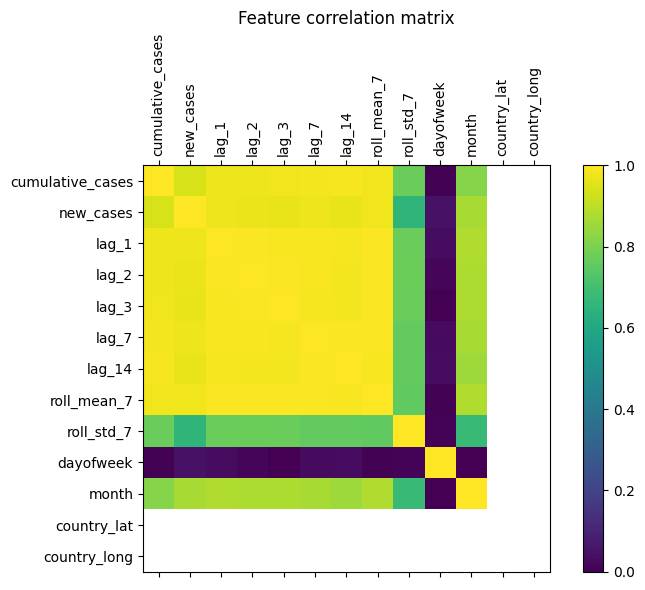

In [23]:
corr = df_ts.corr()
labels = corr.columns.tolist()
fig, ax = plt.subplots(figsize=(8,6))
cax = ax.matshow(corr.values, interpolation='nearest')
fig.colorbar(cax)
ax.set_xticks(range(len(labels))); ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=90); ax.set_yticklabels(labels)
plt.title('Feature correlation matrix'); plt.tight_layout(); plt.show()

In [24]:
X = df_ts.drop(columns=['cumulative_cases','new_cases'])
y = df_ts['new_cases']

In [25]:
test_size = 14
X_train, X_test = X.iloc[:-test_size], X.iloc[-test_size:]
y_train, y_test = y.iloc[:-test_size], y.iloc[-test_size:]

In [26]:
print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (216, 11) Test shape: (14, 11)


In [27]:
baseline_pred = X_test['lag_1'].values

mae = mean_absolute_error(y_test, baseline_pred)
rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

print("Baseline MAE:", mae)
print("Baseline RMSE:", rmse)

Baseline MAE: 10535.785714285714
Baseline RMSE: 23936.692848010563


In [28]:

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

models = {
    'LinearRegression': Pipeline([('scaler', StandardScaler()), ('lr', LinearRegression())]),
    'DecisionTree': Pipeline([('scaler', StandardScaler()), ('dt', DecisionTreeRegressor(random_state=42))]),
    'RandomForest': Pipeline([('scaler', StandardScaler()), ('rf', RandomForestRegressor(n_estimators=200, random_state=42))]),
    'GradientBoosting': Pipeline([('scaler', StandardScaler()), ('gb', GradientBoostingRegressor(random_state=42))])
}

In [29]:
try:
    import xgboost as xgb
    models['XGBoost'] = Pipeline([('scaler', StandardScaler()), ('xgb', xgb.XGBRegressor(n_estimators=200, random_state=42, verbosity=0))])
    print("XGBoost available.")
except Exception as e:
    print("XGBoost not available:", e)


XGBoost available.


In [30]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    # manual RMSE calculation
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    results[name] = {'rmse': rmse, 'mae': mae, 'r2': r2, 'pred': pred}
    print(f"{name} -- RMSE: {rmse:.2f}, MAE: {mae:.2f}, R2: {r2:.3f}")

LinearRegression -- RMSE: 31174.39, MAE: 10662.30, R2: -0.654
DecisionTree -- RMSE: 24807.88, MAE: 10678.64, R2: -0.047
RandomForest -- RMSE: 24011.94, MAE: 11827.53, R2: 0.019
GradientBoosting -- RMSE: 23473.83, MAE: 11273.27, R2: 0.062
XGBoost -- RMSE: 24101.73, MAE: 12023.60, R2: 0.011


In [31]:
comp = pd.DataFrame({'actual': y_test})
for name, info in results.items():
    comp[name+'_pred'] = info['pred']
display(comp.round(2))

,actual,LinearRegression_pred,DecisionTree_pred,RandomForest_pred,GradientBoosting_pred,XGBoost_pred
2020-09-08,89706,88060.52,90802.0,82839.84,81252.01,84259.156250
2020-09-09,95735,90073.03,90802.0,87637.18,89797.70,88109.953125
2020-09-10,96551,95665.31,83883.0,86805.32,88326.39,86745.203125
2020-09-11,97570,94000.89,90802.0,88497.93,89364.77,87121.328125
2020-09-12,94372,93822.93,90802.0,88943.16,89465.31,87989.296875
2020-09-13,92071,94438.77,90802.0,88987.27,90864.53,88019.789062
2020-09-14,83809,88415.92,90802.0,86992.88,84755.93,76603.398438
2020-09-15,90123,94687.41,90802.0,86754.49,85744.61,89579.703125
2020-09-16,97894,98477.83,90802.0,87582.60,87666.91,89419.093750
2020-09-17,96424,98851.44,90802.0,87775.34,87737.89,86698.703125


In [32]:
best = min(results.keys(), key=lambda k: results[k]['rmse'])
print("Best model by RMSE:", best)

Best model by RMSE: GradientBoosting


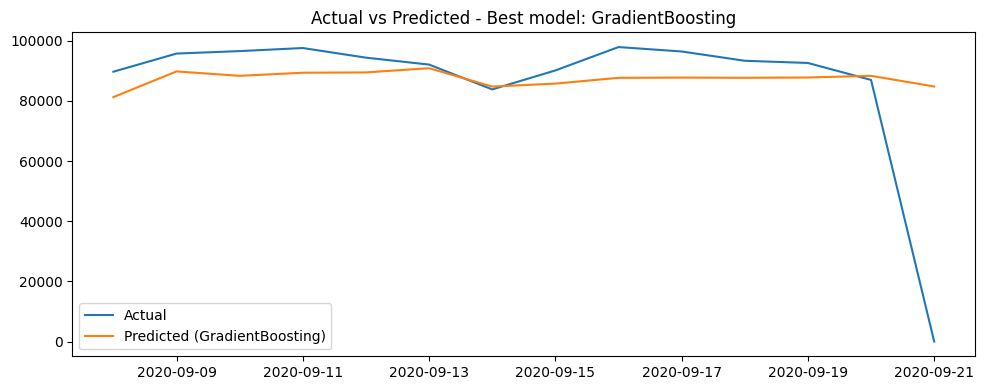

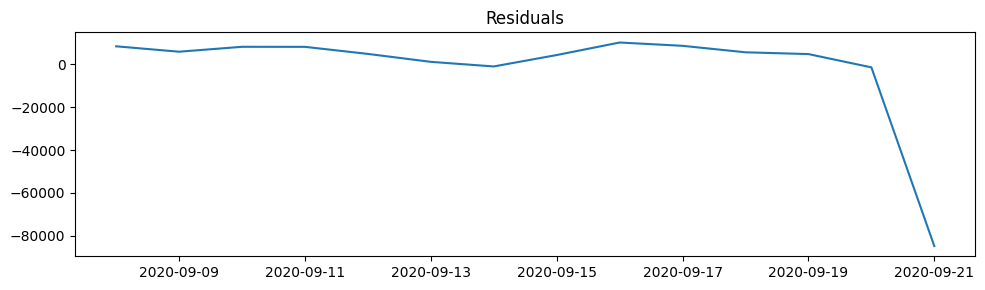

In [33]:
plt.figure(figsize=(10,4))
plt.plot(y_test.index, y_test.values, label='Actual')
plt.plot(y_test.index, results[best]['pred'], label=f'Predicted ({best})')
plt.title(f"Actual vs Predicted - Best model: {best}"); plt.legend(); plt.tight_layout(); plt.show()

resid = y_test.values - results[best]['pred']
plt.figure(figsize=(10,3));
plt.plot(y_test.index, resid);
plt.title('Residuals');
plt.tight_layout();
plt.show()

In [34]:
# Import first
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

tscv = TimeSeriesSplit(n_splits=4)

rf_param_grid = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [5, 10, 15, None],
    'rf__min_samples_split': [2, 5, 10]
}

rf_search = RandomizedSearchCV(
    models['RandomForest'],
    rf_param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_iter=5,
    random_state=42
)
rf_search.fit(X_train, y_train)

rf = RandomForestRegressor(random_state=42)
param_dist_rf = {
    'n_estimators': [100,200,400],
    'max_depth': [5,10,20,None],
    'min_samples_split': [2,5,10],
    'min_samples_leaf': [1,2,4]
}

rs_rf = RandomizedSearchCV(
    rf,
    param_distributions=param_dist_rf,
    n_iter=12,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)
rs_rf.fit(X_train, y_train)



,estimator,RandomForestR...ndom_state=42)
,param_distributions,"{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...]}"
,n_iter,12
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [35]:
import math
print("RandomForest best params:", rs_rf.best_params_)
best_rf = rs_rf.best_estimator_
pred_rf = best_rf.predict(X_test)

# Calculate metrics
rmse = math.sqrt(mean_squared_error(y_test, pred_rf))
mae = mean_absolute_error(y_test, pred_rf)
r2 = r2_score(y_test, pred_rf)

print(f"RandomForest tuned RMSE: {rmse:.2f}")
print(f"RandomForest tuned MAE: {mae:.2f}")
print(f"RandomForest tuned R²: {r2:.3f}")

RandomForest best params: {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
RandomForest tuned RMSE: 23956.45
RandomForest tuned MAE: 11897.33
RandomForest tuned R²: 0.023


In [36]:
# XGBoost tuning (optional)
best_xgb = None
try:
    import xgboost as xgb
    xgb_model = xgb.XGBRegressor(random_state=42, verbosity=0)
    param_dist_xgb = {
        'n_estimators': [100,200,400],
        'max_depth': [3,5,8],
        'learning_rate': [0.01, 0.05, 0.1]
    }
    rs_xgb = RandomizedSearchCV(xgb_model, param_distributions=param_dist_xgb, n_iter=8, cv=tscv, scoring='neg_root_mean_squared_error', random_state=42, n_jobs=-1)
    rs_xgb.fit(X_train, y_train)
    best_xgb = rs_xgb.best_estimator_
    pred_xgb = best_xgb.predict(X_test)
    print("XGBoost tuned RMSE:", mean_squared_error(y_test, pred_xgb, squared=False))
except Exception as e:
    print("XGBoost tuning skipped:", e)

XGBoost tuning skipped: got an unexpected keyword argument 'squared'


# Covid Prediction System 

 ## Data Preparation:

## Dataset Description

## Data Aggregation

## Feature Engineering

## Exploratory Data Analysis (EDA)

## Train-Test Split

## Model Building

## Hyperparameter Tuning

## Model Evaluation